## Overview

**fasterbench** is a comprehensive benchmarking toolkit for PyTorch models. It measures five critical dimensions of model performance:

| Metric | What It Measures | Why It Matters |
|--------|------------------|----------------|
| **Size** | Disk size, parameter count | Deployment storage, download time |
| **Speed** | Latency, throughput | User experience, serving costs |
| **Compute** | MACs (operations) | Hardware requirements, energy use |
| **Memory** | Peak/average memory | GPU memory limits, batch sizes |
| **Energy** | Power, CO₂ emissions | Operating costs, sustainability |

### Key Features

- **Typed results** - `BenchmarkResult` with IDE autocomplete
- **Backward compatible** - Dict-like access for existing code
- **Selective metrics** - Benchmark only what you need
- **Multi-device** - CPU, CUDA, and multi-GPU support
- **Export formats** - DataFrame, JSON, summary reports

## 1. Basic Benchmarking

The `benchmark()` function is the main entry point:

In [ ]:
import torch
from torchvision.models import resnet18, mobilenet_v3_large, efficientnet_b0
from fasterbench import benchmark, BenchmarkResult

# Create sample input
dummy = torch.randn(1, 3, 224, 224)

# Benchmark a model (using fast metrics for demo)
result = benchmark(resnet18(), dummy, metrics=["size", "speed", "compute"])
result

═══ Size ════════════════════════════════════
  Disk:   44.67 MiB
  Params: 11.69M
═══ Speed ═══════════════════════════════════
  cpu: 33.59 ms  │  29.8 inf/s  │  p99: 61.68 ms
  cuda: 0.64 ms  │  1562.1 inf/s  │  p99: 0.66 ms
═══ Compute ═════════════════════════════════
  MACs: 1824.0 M

## 2. Typed Access

`BenchmarkResult` provides typed access to all metrics with IDE autocomplete:

In [ ]:
# Size metrics
print(f"Disk size: {result.size.size_mib:.2f} MiB")
print(f"Parameters: {result.size.num_params:,}")

# Speed metrics (keyed by device)
print(f"\nCPU latency: {result.speed['cpu'].mean_ms:.2f} ms")
print(f"CPU throughput: {result.speed['cpu'].throughput_s:.1f} inf/s")
print(f"CPU p99 latency: {result.speed['cpu'].p99_ms:.2f} ms")

# Compute metrics
print(f"\nMACs: {result.compute.macs_m:.1f} M")
print(f"MACs available: {result.compute.macs_available}")

Disk size: 44.67 MiB
Parameters: 11,689,512

CPU latency: 33.59 ms
CPU throughput: 29.8 inf/s
CPU p99 latency: 61.68 ms

MACs: 1824.0 M
MACs available: True


## 3. Backward-Compatible Dict Access

For compatibility with existing code, `BenchmarkResult` also supports dict-like access:

In [ ]:
# Dict-style access
print(result["size_size_mib"])
print(result["speed_cpu_mean_ms"])

# Iteration
print("\nAll metrics:")
for key, value in result.items():
    print(f"  {key}: {value}")

44.66535472869873
33.58930969238281

All metrics:
  size_disk_bytes: 46835019
  size_size_mib: 44.66535472869873
  size_num_params: 11689512
  speed_cpu_p50_ms: 29.3856258392334
  speed_cpu_p90_ms: 37.92195129394532
  speed_cpu_p99_ms: 61.68484344482422
  speed_cpu_mean_ms: 33.58930969238281
  speed_cpu_std_ms: 11.55258846282959
  speed_cpu_throughput_s: 29.77137693981172
  speed_cuda_p50_ms: 0.6376160085201263
  speed_cuda_p90_ms: 0.6466431796550751
  speed_cuda_p99_ms: 0.6631737768650058
  speed_cuda_mean_ms: 0.6401805281639099
  speed_cuda_std_ms: 0.009303152561187744
  speed_cuda_throughput_s: 1562.0593816998492
  compute_macs_m: 1824.034


## 4. Comparing Multiple Models

Export results to a pandas DataFrame for easy comparison:

In [ ]:
import pandas as pd

# Benchmark multiple models
models = {
    "ResNet-18": resnet18(),
    "MobileNet-V3": mobilenet_v3_large(),
    "EfficientNet-B0": efficientnet_b0(),
}

results = {}
for name, model in models.items():
    results[name] = benchmark(model, dummy, metrics=["size", "speed", "compute"])

# Combine into DataFrame
rows = []
for name, r in results.items():
    row = {"model": name, **r.as_dict()}
    rows.append(row)

df = pd.DataFrame(rows)
df[["model", "size_size_mib", "size_num_params", "speed_cpu_mean_ms", "compute_macs_m"]]

,model,size_size_mib,size_num_params,speed_cpu_mean_ms,compute_macs_m
0,ResNet-18,44.665355,11689512,36.195747,1824.034
1,MobileNet-V3,21.107375,5483032,9.795851,234.838
2,EfficientNet-B0,20.453475,5288548,15.414814,415.145


## 5. JSON Export

Serialize results to JSON for logging or storage:

In [ ]:
# Export to JSON
json_str = result.to_json()
print(json_str)

{
  "size_disk_bytes": 46835019,
  "size_size_mib": 44.66535472869873,
  "size_num_params": 11689512,
  "speed_cpu_p50_ms": 29.3856258392334,
  "speed_cpu_p90_ms": 37.92195129394532,
  "speed_cpu_p99_ms": 61.68484344482422,
  "speed_cpu_mean_ms": 33.58930969238281,
  "speed_cpu_std_ms": 11.55258846282959,
  "speed_cpu_throughput_s": 29.77137693981172,
  "speed_cuda_p50_ms": 0.6376160085201263,
  "speed_cuda_p90_ms": 0.6466431796550751,
  "speed_cuda_p99_ms": 0.6631737768650058,
  "speed_cuda_mean_ms": 0.6401805281639099,
  "speed_cuda_std_ms": 0.009303152561187744,
  "speed_cuda_throughput_s": 1562.0593816998492,
  "compute_macs_m": 1824.034
}


## 6. Human-Readable Summary

Get a quick overview of all metrics with `summary()`:

In [ ]:
result.summary()

═══ Size ════════════════════════════════════
  Disk:   44.67 MiB
  Params: 11.69M
═══ Speed ═══════════════════════════════════
  cpu: 33.59 ms  │  29.8 inf/s  │  p99: 61.68 ms
  cuda: 0.64 ms  │  1562.1 inf/s  │  p99: 0.66 ms
═══ Compute ═════════════════════════════════
  MACs: 1824.0 M


## 7. Selective Metrics

Only compute what you need for faster benchmarking:

In [ ]:
quick_result = benchmark(resnet18(), dummy, metrics=["size", "compute"])
print(f"Size: {quick_result.size.size_mib:.2f} MiB")
print(f"MACs: {quick_result.compute.macs_m:.1f} M")
print(f"Speed measured: {bool(quick_result.speed)}")  # False - not requested

Size: 44.67 MiB
MACs: 1824.0 M
Speed measured: False


## 8. Visualizing with Radar Plots

Compare models visually using radar plots:

In [ ]:
from fasterbench.plot import create_radar_plot

# Full benchmark for radar plot (includes energy)
dummy_batch = torch.randn(8, 3, 224, 224)

resnet_full = benchmark(resnet18(), dummy_batch,
                        metrics=["size", "speed", "compute", "energy"])
mobilenet_full = benchmark(mobilenet_v3_large(), dummy_batch,
                           metrics=["size", "speed", "compute", "energy"])

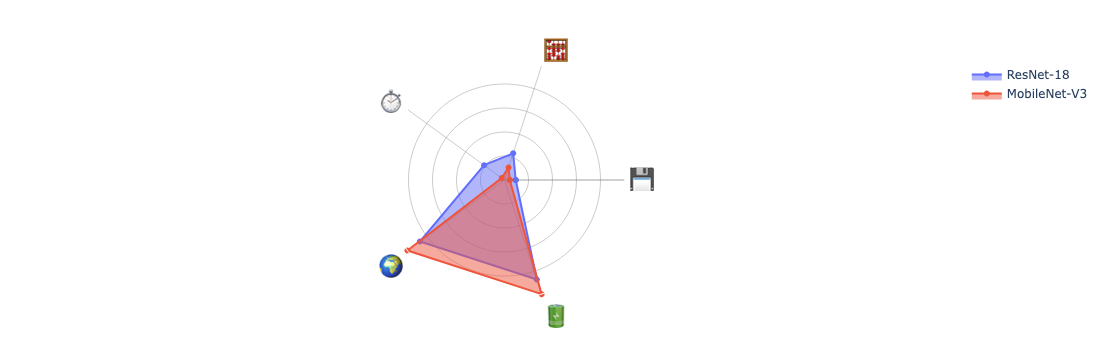

In [ ]:
# Create radar plot comparing models
fig = create_radar_plot(
    [resnet_full, mobilenet_full],
    model_names=["ResNet-18", "MobileNet-V3"]
)
fig.show()

## Summary

| Feature | Description |
|---------|-------------|
| **`benchmark()`** | Main entry point for comprehensive benchmarking |
| **`BenchmarkResult`** | Typed container with IDE autocomplete |
| **Dict access** | Backward-compatible `result["key"]` access |
| **`summary()`** | Human-readable formatted output |
| **`to_dataframe()`** | Export to pandas DataFrame |
| **`to_json()`** | Serialize to JSON string |
| **`create_radar_plot()`** | Visual model comparison |

---

## See Also

- [Layer Profiling Tutorial](profiling.html) - Per-layer performance analysis
- [Sensitivity Analysis Tutorial](sensitivity.html) - Find bottleneck layers
- [Benchmark API](../analysis/benchmark.html) - Full API reference
- [Individual Metrics](../metrics/size.html) - Size, speed, compute, memory, energy modules